<figure style="float: right; width: 150; margin-right: 5px; border:5px solid white; padding:5px; background-color: #f9f9f9;">
    <a href="https://frba.utn.edu.ar/electronica/" target="_blank" rel="noopener noreferrer">
        <img src="./img/logo_UTN.svg" width="150" alt="Ergometría" />
    </a>
</figure>

# Filtros FIR recursivos e interpolados: Aplicaciones a la electrocardiografía

#### Por Mariano Llamedo Soria



### Resumen 

En este notebook se ejemplifica el diseño de filtros FIR mediante el algoritmo de Parks-McClellan (PM).

* Análisis de la respuesta en frecuencia: [plot_plantilla](https://pytc2.readthedocs.io/en/latest/autoapi/pytc2/sistemas_lineales/index.html#pytc2.sistemas_lineales.plot_plantilla)
* Funciones de diseño digital [SciPy remez](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.remez.html#scipy.signal.remez), [PyTC2 fir_design_pm](https://pytc2.readthedocs.io/en/latest/autoapi/pytc2/filtros_digitales/index.html#pytc2.filtros_digitales.fir_design_pm)


## Introducción

### Filtros FIR de fase lineal

En los [notebooks anteriores](aplicaciones_FIR_simetricos.ipynb) revisamos los filtros de respuesta finita, o FIR, y sus principales virtudes:

* **Estabilidad**, ya que todos sus polos se encuentran en el origen.
* **Fase lineal**, debido a la simetría de la respuesta al impulso.
* **Retardo constante**, como consecuencia de la linealidad de fase.

Tales ventajas van en detrimento del costo computacional por muestra de salida calculada. Es decir, de la cantidad de multiplicaciones y sumas, como también de la cantidad de unidades de memoria necesarias para su implementación. En este notebook se evaluará la posibilidad de implementar ciertos FIR de manera recursiva, sin afectar los beneficios antedichos. Como se verá, el costo computacional por muestra de salida disminuirá considerablemente.

Recordando que la respuesta en frecuencia de un FIR de respuesta simétrica (tipos I o II) se expresan de forma polar como:

$$
H(\Omega) = H_R(\Omega) \cdot e^{j \cdot \varphi(\Omega)}
$$

donde la fase es

$$
\varphi(\Omega) = \Omega \cdot (-\frac{N-1}{2}) = \Omega \cdot (-M)
$$

siendo $M$ el eje de simetría temporal de la respuesta al impulso, coincidiendo con la muestra media para un filtro de $N$ coeficientes, y sobretodo, con el **retardo del filtro** constante para toda frecuencia. Luego su *respuesta de fase cero* será

$$
H_R(\Omega) = Q(\Omega) \cdot A(\Omega)
$$

estando relacionada con la respuesta de módulo mediante $ \left| H(\Omega) \right| = \left| H_R(\Omega) \right| $.

$$
A(\Omega) = \sum_{k=0}^{M-1} a(k) \cdot \cos(k \Omega)
$$

 Luego $Q(\Omega)$ será una función par para estos dos tipos de FIR, dependiendo del largo $nn$, como se ve en la siguiente tabla.

| **Tipo** | $ Q(\Omega) $ | $H_R(0)$ | $H_R(\pi)$ | Transferencias posibles |
|----------|----------|------------|---------------|---------------|
| **I**    | 1 | $A(\Omega)$        | $A(\Omega)$          | LP-H-BP |
| **II**   | $ \cos{(\Omega/2)} $ | $A(\Omega)$        | 0          | LP-BP         |


Vemos que el tipo I será el más versátil, ya que permite diseñar cualquier respuesta, mientras que el tipo II, al forzar un 0 en *Nyquist* restringe las posibilidades.

En principio se rediseñará un filtro FIR promediador (pasabajos), para convertirlo en un filtro **FIR recursivo**. Luego se usarápara resolver un problema concreto: diseñar un FIR pasa-altos con un cero en $\Omega=0$ (DC). Por último, mediante el concepto de interpolación de la respuesta al impulso, se convertirá en un *filtro peine* particularmente útil para el preprocesamiento del ECG. Se presentará la comparación con otros FIR diseñados mediante el resto de metodologías vistas hasta ahora.


### La señal electrocardiográfica (ECG)

<figure style="float: right; width: 300px; margin-right: 10px; border:10px solid white; padding:10px; background-color: #f9f9f9;">
  <img src="./img/ergo_iss.jpg" width="300" alt="Ergometría" />
  <figcaption style="font-size: 0.9em; color: #555;">
    CC BY-SA 3.0. 
    <a href="https://commons.wikimedia.org/wiki/File:Stress_test.jpg" target="_blank" rel="noopener noreferrer">
      Wikipedia
    </a>, 
  </figcaption>
</figure>


El electrocardiograma de superficie (ECG) es una medición no invasiva del potencial eléctrico producido por el dipolo eléctrico resultante en cada célula cardíaca. Por lo general, para la medición del ECG se colocan electrodos en las extremidades del cuerpo y sobre la superficie del torso, como se aprecia en la figura. Debido a que es una técnica no invasiva y su costo no es elevado, es ampliamente utilizada en la clínica médica para conocer la funcionalidad del corazón. Habitualmente se miden entre una y doce señales de ECG dependiendo de la patología bajo análisis.


<figure style="float: left; width: 300px; margin-right: 10px; border:10px solid white; padding:10px; background-color: #f9f9f9;">
  <img src="./img/EKG_Complex_es.png" width="300" alt="Complejo EKG" />
  <figcaption style="font-size: 0.9em; color: #555;">
    CC BY-SA 3.0. 
    <a href="https://commons.wikimedia.org/w/index.php?curid=31447636" target="_blank" rel="noopener noreferrer">
      Wikipedia
    </a>, 
  </figcaption>
</figure>

La señal de ECG también es afectada por los campos eléctricos generados por todas las otras fuentes biológicas del organismo bajo estudio (ruido muscular), como también por otros factores como el movimiento de los electrodos sobre la piel y el acople de la línea eléctrica (50/60 Hz) entre otros. Una de las primeras tareas previas al análisis del ECG es el filtrado de interferencias. En el siguiente ejemplo, procederemos al filtrado de un ECG registrado durante una prueba de esfuerzo o ergometría. En dichos registros, las interferencias musculares son muy exageradas dado al esfuerzo físico al que es sometido el paciente.


Para tal fin, se procede a procesar la señal de ECG con diferentes filtros digitales, especialmente los FIR para evitar los efectos distorsivos causados por la alinealidad de la fase.


### Un FIR de fase lineal para remover contínua

Un problema fácil de explicar, pero difícil de lograr como tantos en la Ingeniería. En esta sección se retoma un artículo de 2008 de [Rick Lyons en dsprelated.com](https://www.dsprelated.com/showarticle/58.php) donde trató este tema desde una perspectiva muy interesante, ya que convierte al filtro FIR promediador de $N$ muestras

$$
y(n) = \frac{1}{N} \sum_{i=0}^{N-1} x(n-i)
$$

cuya transferencia es

$$
T(z) = \frac{1}{N} \sum_{i=0}^{N-1} z^{-i} = \frac{1}{N} \frac{\sum_{i=0}^{N-1} z^{i}}{z^{N-1}}
$$

en una versión recursiva de la misma transferencia

$$
y_R(n) = x(n) + y_R(n-1) - x(n-N)
$$

Si bien a primera vista cuesta entender la equivalencia entre ambas expresiones, conviene pensar el cálculo del promedio entre dos muestras consecutivas. La sumatoria en $y(n)$ e $y(n-1)$ tendrá $N-2$ términos comunes, salvo el primer y último término, es decir $x(n)$ e $x(n-N)$. Luego aplicando *transformada z* llegamos a la consecuente transferencia recursiva

$$
T_R(z) = \frac{1}{N} \frac{1 - z^{-N}}{1 - z^{-1}}
$$

Del mismo modo uno pensaría que esta transferencia **no es estable**, salvo porque se da una cancelación polo-cero para $\Omega = 0$ para todo N, resultando $T(z) = T_R(z)$. De esta forma, un promedio de N muestras pasa de costar N sumas a **tan solo 2 sumas, para todo N**, como se ve en el siguiente esquema

<div style="text-align: center;">
  <img src="./img/rrs.svg" width="500" alt="Filtro CIC" style="display: block; margin: 0 auto;" />
  <div style="font-size: 0.9em; color: #555; margin-top: 5px;">
    $T_R(z)$ — 
    <a href="https://commons.wikimedia.org/w/index.php?curid=31447636" target="_blank" rel="noopener noreferrer">
      Filtro promediador recursivo ó CIC
    </a>
  </div>
</div>

Esto se ve claramente en los siguientes ejemplos

/home/mariano/pytc2_dev/lib/python3.12/site-packages/scipy/signal/_filter_design.py:482: RuntimeWarning: invalid value encountered in divide
  h = (npp_polyval(zm1, b, tensor=False) /
/home/mariano/Downloads/github/pytc2/src/pytc2/sistemas_lineales.py:2402: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig_hdl = plt.figure(fig_id, figsize=(12, 5))
/home/mariano/Downloads/github/pytc2/src/pytc2/sistemas_lineales.py:1480: UserWarning: Ignoring specified arguments in this call because figure with num: 3 already exists
  fig_hdl = plt.figure(fig_id, figsize=(8, 8))
/home/mariano/pytc2_dev/lib/python3.12/site-packages/scipy/signal/_filter_design.py:482: RuntimeWarning: invalid value encountered in divide
  h = (npp_polyval(zm1, b, tensor=False) /
/home/mariano/Downloads/github/pytc2/src/pytc2/sistemas_lineales.py:2051: UserWarning: Ignoring specified arguments in this call because figure with num: 4 already exists
  fig_hdl = plt.figure(f

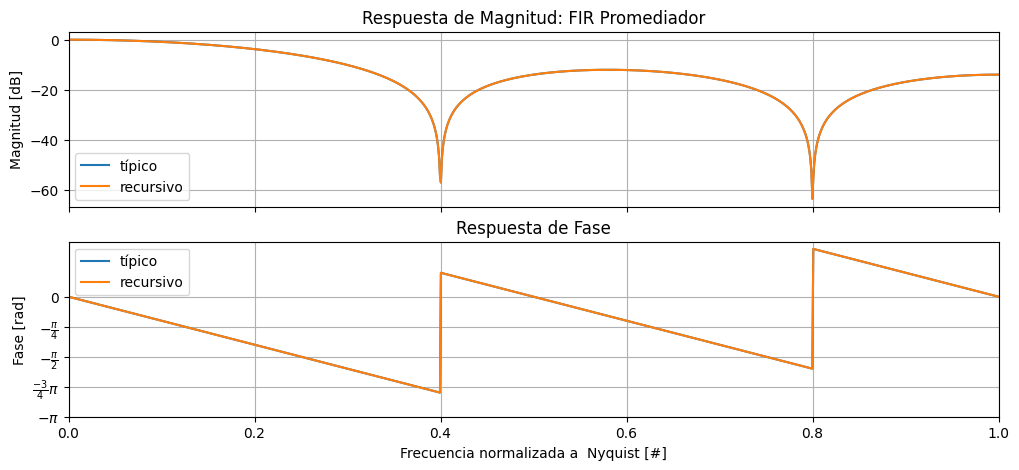

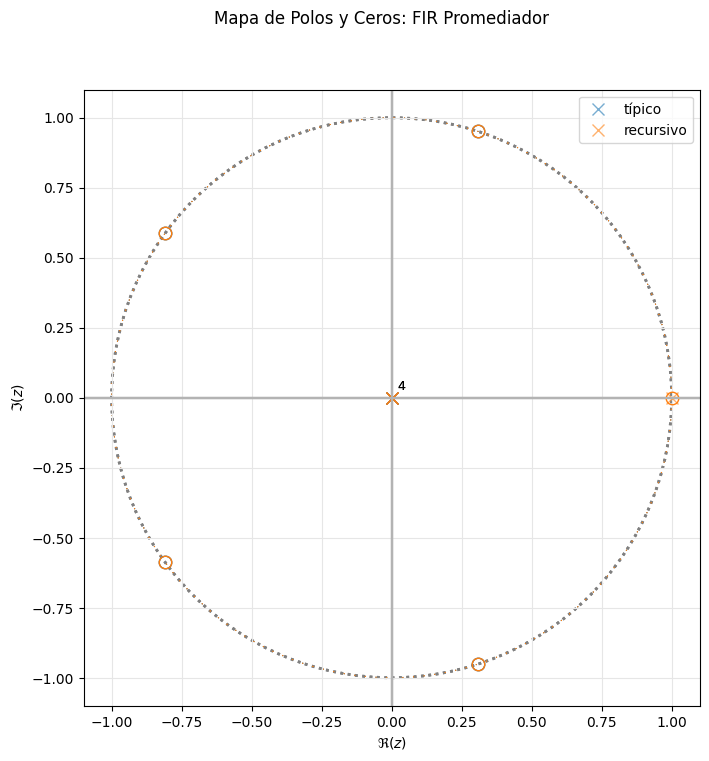

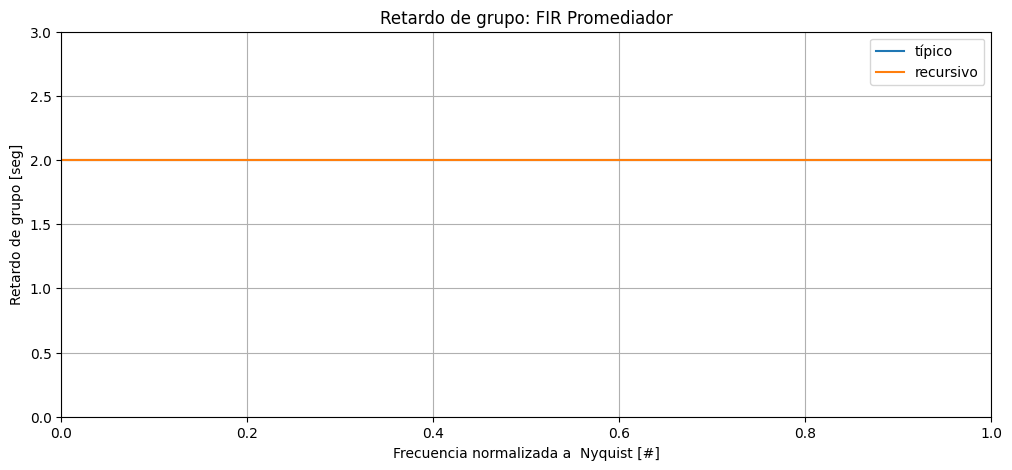

In [36]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

from pytc2.sistemas_lineales import group_delay, analyze_sys, plot_plantilla
from pytc2.general import print_latex, print_subtitle, a_equal_b_latex_s, simplify_n_monic

nn = 5
fs = 2

# Promediador de orden nn
# TransferFunction los asume en potencias decrecientes
num = 1/(nn)* np.ones(nn)
den = np.zeros(nn)
den[0] = 1

my_df = sig.TransferFunction(num, den, dt=1/fs)

# Promediador de orden N recursivo
# TransferFunction los asume en potencias decrecientes
num_R = 1/nn*np.concatenate([[1], np.zeros(nn-1),[-1]])
den_R = np.zeros(nn+1)
den_R[:2] = np.array([1, -1]) 

my_df_R = sig.TransferFunction(num_R, den_R, dt=1/fs)

plt.close('all')
# Visualizamos su respuesta en frecuencia
figaxes = analyze_sys([my_df, my_df_R], ['típico', 'recursivo'], title_suffix = ': FIR Promediador', annotations=False, fs=fs)



Este filtro pasabajos recursivo, también se lo conoce en otros ámbitos como [*cascaded integrator comb* (CIC)](https://en.wikipedia.org/wiki/Cascaded_integrator%E2%80%93comb_filter), como sugiere su respuesta de módulo.

### Filtros de Complementariedad de Demora

Lo interesante de esta transferencia, es que se la puede utilizar para lograr un pasa-altos, mediante el concepto de *complementaridad de demora*, es decir

$$
T(z) + T_H(z) = 1 . z^{-\frac{N-1}{2}} = z^{-M}
$$

esto significa que para un filtro $T(z)$ de $N$ coeficientes, cuya demora es $\frac{N-1}{2}$ ó $M$ como se definió más arriba para el tipo I. Entonces los módulos de ambos filtros deben respetar que

$$
\left| T(\Omega) +  T_H(\Omega) \right|  = 1 
$$

Es decir, que se complementen en módulo. Luego, el filtro que buscamos surge como el complementario a nuestro pasabajos recursivo, es decir

$$
T_{H}(z) = z^{-M} - T_R(z) = z^{-\frac{N-1}{2}} - \frac{1}{N} \frac{1 - z^{-N}}{1 - z^{-1}}
$$

$$
T_{H}(z) = \frac{1}{N} \frac{-1 + N . z^{-\frac{N-1}{2}} - N . z^{-\frac{N+1}{2}} +  z^{-N} }{1 - z^{-1}}
$$

Según comenta Lyons, conviene que N sea par para que la implementación del filtro sea aún más eficiente, siendo el producto $1/N$ una mera rotación de bits. Esto conlleva que la demora $M$ **no sea entera**, sin embargo, puede solventarse cascadeando una **cantidad par** ($C$) de CIC's, es decir

$$
T_C(z) = z^{-M.C} - T_R^{C}(z) = z^{-\frac{(N-1).C}{2}} - \left( \frac{1}{N} \frac{1 - z^{-N}}{1 - z^{-1}} \right)^C
$$

entonces ejempificando para un caso sencillo como $C = 2$, se llega a

$$
T_C(z) = T_2(z) = z^{-(N-1)} - \left( \frac{1}{N} \frac{1 - z^{-N}}{1 - z^{-1}} \right)^2 
$$

$$
T_2(z) = z^{-(N-1)} - \frac{1}{N^2} \frac{1 - 2.z^{-N} + z^{-2N} }{1 -2.z^{-1} + z^{-2}}.
$$

 Cuyo diagrama en bloques se ve a continuación 

<div style="text-align: center;">
  <img src="./img/rrs hp.svg" width="800" alt="Filtro CIC" style="display: block; margin: 0 auto;" />
  <div style="font-size: 0.9em; color: #555; margin-top: 5px;">
    $T_C(z)$ para $C = 2$.
  </div>
</div>

Que de forma más explícita se puede expresar como

$$
T_C(z) = T_2(z) = \frac{1}{N^2} \cdot \frac{-1 + N^2.z^{-(N-1)} -  (2 + 2.N^2).z^{-N} +  N^2.z^{-(N+1)} - z^{-2N} }{ 1 -2.z^{-1} + z^{-2} }
$$

Luego, reordenando y reutilizando algunas estructuras en pos de la eficiencia computacional se puede llegar a la estructura que propone [Lyons en otro artículo en *dsprelated*](https://www.dsprelated.com/showarticle/1383.php)

<div style="text-align: center;">
  <img src="./img/rrs hp2.svg" width="800" alt="Filtro CIC" style="display: block; margin: 0 auto;" />
  <div style="font-size: 0.9em; color: #555; margin-top: 5px;">
    $T_C(z)$ para $C = 2$. 
    <a href="https://www.dsprelated.com/showarticle/1383.php" target="_blank" rel="noopener noreferrer">
       Modificado de la Fig. 1 en dsprelated
    </a>
  </div>
</div>

####

Como se puede anticipar, generalizarlo para otros valores de $C$ da lugar a coeficientes **más espaciados**, producto de aumentar la demora. Es decir que a medida que escala $N$ y $C$, los coeficientes del numerador y denominador se hacen más dispersos, es decir aumenta la proporción de  coeficientes nulos. Este hecho es **muy significativo para la eficiencia computacional**, y cuando se interpole esta respuesta, se ampliará aún más la escacez o proporción de coeficientes nulos (*sparsity* en inglés). 

#### Análisis simbólico

Dado que a partir de este punto la complejidad algebraica escala, surge la necesidad de continuar mediante un **análisis simbólico**, comenzamos reproduciendo los mismos resultados que se presentaron más arriba

In [14]:
import sympy as sp
from IPython.display import display
from pytc2.general import print_latex, print_subtitle, a_equal_b_latex_s

z = sp.symbols('z', complex=True)
N, C = sp.symbols('N, C', real=True, positive=True)

# moving average
Tma = 1/N * (1-z**(-N))/(1-z**(-1))

# delay line of (N-1)/2
Tdl =  z**(-(N-1)/2)

num, den = (Tdl - Tma).as_numer_denom()

num = (sp.expand(num/(N*z**(N+1)))).powsimp()
den = (sp.expand(den/(N*z**(N+1)))).powsimp()

Tdc_removal = num/den

print_latex(a_equal_b_latex_s('T_{H}(z)', Tdc_removal ))

# Según Rick Lyons, este sistema sería muy bueno para implementarse
# con N múltiplo de 2**NN, dado que el escalado por N sería simplemente 
# una rotación a nivel de bits de NN veces a la derecha, y su implementación
# no necesitaría de multiplicaciones. Sin embargo esta elección impone un 
# retardo no entero. Por esta razón se opta por poner dos (incluso cuatro) 
# sistemas idénticos en cascada.

# Probamos primero con 2 moving average

Tdc_removal_2 = z**-(N-1) - Tma**2

# emprolijamos la expresion a mano
num, den = Tdc_removal_2.as_numer_denom()
num = (sp.expand(num/(N**2*z**(2*N+2))).powsimp())
den = (sp.expand(den/(N**2*z**(2*N+2))).powsimp())

Tdc_removal_2 = num/den

#display(Tdc_removal_2)

print_latex(a_equal_b_latex_s('T_C(z) = T_2(z)', Tdc_removal_2 ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Si bien no es la misma expresión, se puede verificar que estas expresiones son equivalentes a las presentadas más arriba. Esto se debe a los algoritmos de simplificación que usa **SymPy**. Ahora si probaremos para C = 4 y 6 sólo para tener una idea de cómo escala la expresión. Recordar que solamente tiene sentido la elección de $C$ pares, debido al **retardo no entero para $N$ pares**.

In [17]:
# Con 4 promediadores

Tdc_removal_C = z**-(N-1)*C - Tma**C

cc = sp.Rational(4)
# emprolijamos la expresion
num, den = (Tdc_removal_C.subs(C, cc)).as_numer_denom()
num = (sp.expand(num/(N**cc*z**(cc*N+cc)))).powsimp()
den = (sp.expand(den/(N**cc*z**(cc*N+cc)))).powsimp()

Tdc_removal_cc = num/den

print_latex(a_equal_b_latex_s(f'T_{cc}(z)', Tdc_removal_cc ))

# Con 6 promediadores

cc = sp.Rational(6)
Tdc_removal_cc = Tdc_removal_C.subs(C, cc)
# emprolijamos la expresion
num, den = Tdc_removal_cc.as_numer_denom()
num = (sp.expand(num/(N**cc*z**(cc*N+cc)))).powsimp()
den = (sp.expand(den/(N**cc*z**(cc*N+cc)))).powsimp()

Tdc_removal_cc = num/den

print_latex(a_equal_b_latex_s(f'T_{cc}(z)', Tdc_removal_cc ))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Análisis numérico de la respuesta en frecuencia

Ahora que se tiene una buena idea de la expresión matemática de las transferencias pasa-alto de $T_C(z)$, se procederá a analizar la respuesta en frecuencia numérica. Para ello se usará una implementación que se incluye en PyTC2 mediante una clase de filtros, un tanto más complejos, llamada *DC_PWL_removal_recursive_filter*. Las transferencias pasa-alto $T_{C}(z)$ analizadas más arriba, pueden implementarse mediante esta clase, omitiendo los parámetros  *upsample* y *fpwl*, que explicarán más abajo.

/tmp/ipykernel_28473/3954100212.py:23: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w_theoretical, 20*np.log10(np.abs(H_theoretical)), label=f'$T_{C}(z)$: N={nn} C={cc}')


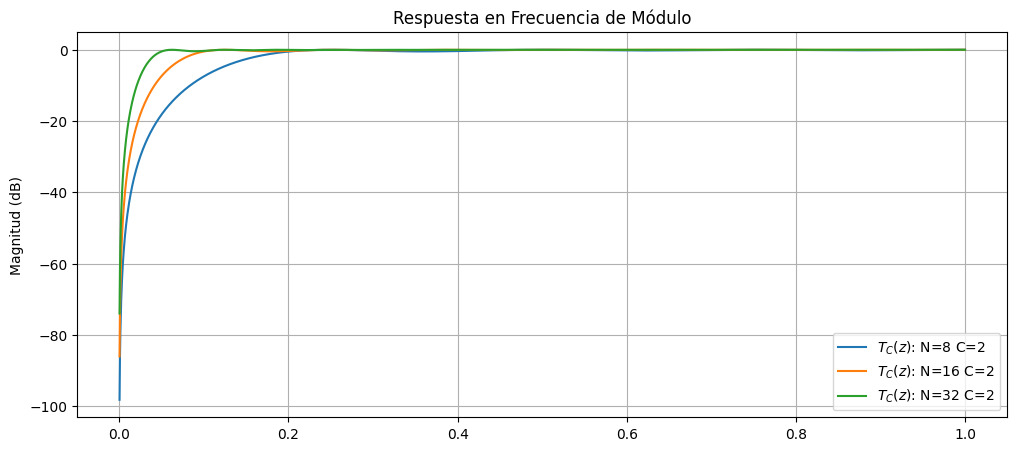

In [18]:
# importamos la clase donde se implementa el filtro
from pytc2.filtros_digitales import DC_PWL_removal_recursive_filter

# cantidad de muestras promediadas
NN = [8, 16, 32]

# cantidad de promediadores
cc = 2

fig = plt.figure(figsize=(12, 5))

for nn in NN:
    
    # algunos parámetros se explicarán más abajo
    t_filter = DC_PWL_removal_recursive_filter(samp_avg = nn, upsample = 1, cant_ma = cc, fpwl = 0.2 )
    
    w_theoretical, H_theoretical = t_filter.frequency_response(bTeorica=True)
    
    # normalization
    w_theoretical = w_theoretical / np.pi
    
    # Gráficos comparativos
    plt.plot(w_theoretical, 20*np.log10(np.abs(H_theoretical)), label=f'$T_{C}(z)$: N={nn} C={cc}')


plt.title(f'Respuesta en Frecuencia de Módulo')
plt.ylabel('Magnitud (dB)')
ax = plt.gca()
plt.legend()
plt.grid(True)


En la figura anterior se respresenta la excelente respuesta de módulo de $T_2(z)$ en toda la banda. Se nota claramente la presencia de un cero de transmisión en DC y un bajo *ripple* u ondulación de la respuesta, especialmente en baja frecuencia. Ahora se continuará analizando en detalle ambos aspectos.

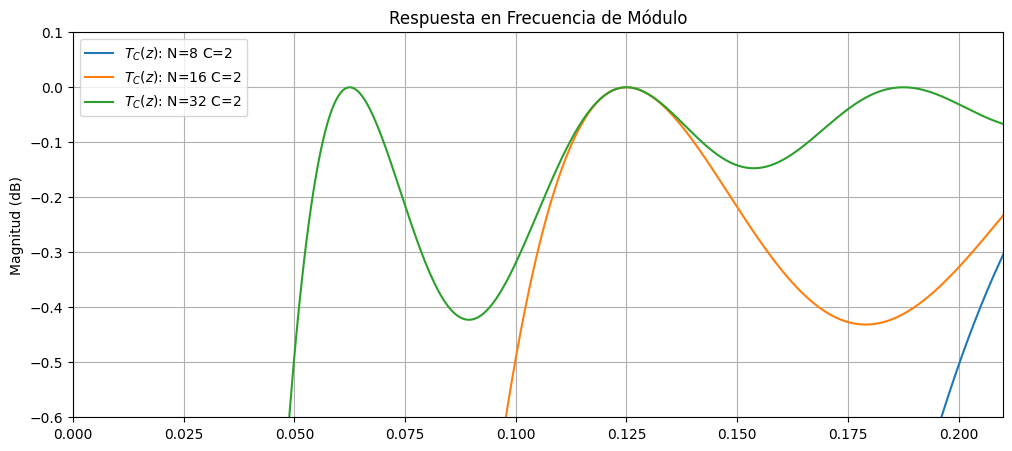

In [5]:
ax.set_ylim( [-.6, .1 ])
ax.set_xlim( [0, .21 ])
fig

En este caso se analiza la rapidez o pendiente con la que se transiciona a la banda de paso. Tomando como referencia el nivel de $T_2(\Omega_C)= -0.5 $ dB, se nota claramente como aumenta la pendiente con el aumento de $N$. En general, puede verse que el *ripple* máximo parece estar holgadamente por encima de -0.5 dB para todos los $N$ analizados. A continuación se analiza la banda de *stop* o detenida.

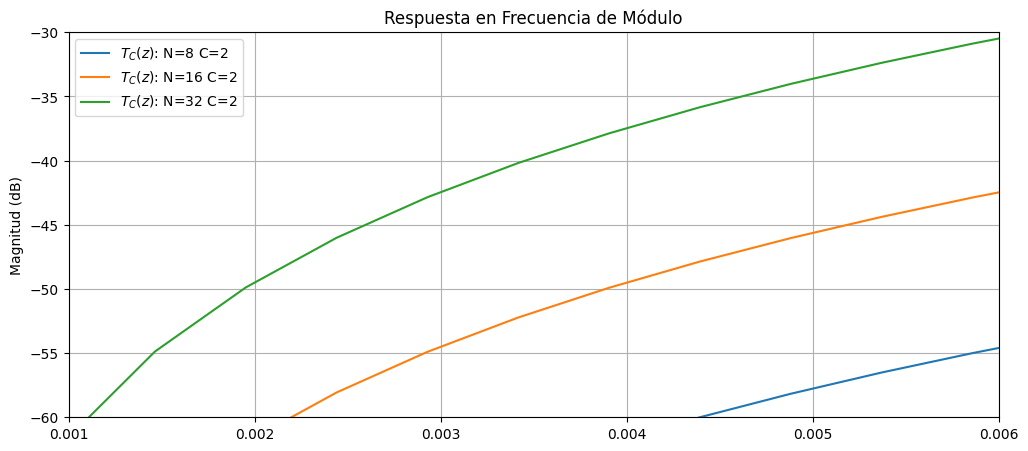

In [6]:
ax.set_ylim( [-60, -30 ])
ax.set_xlim( [0.001, .006 ])
fig

Se toma como referencia para el final de la banda de *stop* la frecuencia $\Omega_S$, que se define como $T_2(\Omega_S)= -60 $ dB. En la siguiente tabla se resumen algunas características de la respuesta de magnitud. Se observa cómo aumenta la pendiente de transición y en consecuencia el ancho de banda (BW) del filtro de manera pronunciada.

| **N** | **$\Omega_S$** | **$\Omega_C$** | **BW** |
|-------|----------------|----------------|--------|
| 8     | 0.0044          | 0.2            | 0.8    |
| 16    | 0.0023           | 0.1            | 0.9    |
| 32    | 0.0011           | 0.05           | 0.95   |

El rendimiento de la respuesta de módulo analizado, junto con su fase lineal y el bajo costo computacional por muestra, dan cuenta de las **excelentes características de este filtro**. Recordar que la implementación de las respuestas anteriores toman $2.C$ sumas y 1 producto, **para cualquier cantidad de muestras $N$**. Sin embargo, la cantidad de posiciones de memoria necesarias sí escala con $N$, **y en consecuencia también crece el retardo del filtro**. 

Siguiendo la metodología propuesta por Herrmann *et.al.* [1], calculamos la cantidad de coeficientes, que es proporcional al costo computacional, para las transiciones de los filtros presentados más arriba, con un *ripple* de 0.5 dB y una atenuación de -60 dB.


In [7]:
from pytc2.filtros_digitales import herrmann_lp_fir_order

omega_S = [0.0044, 0.0023, 0.0011]
omega_C = [0.2, 0.1, 0.05]

for ii, (wc, ws) in enumerate(zip(omega_C, omega_S)):
    
    cant_coef  = herrmann_lp_fir_order([ws*np.pi, wc*np.pi], [0.5, 60], ripple_in_db=True)
    cant_coef  =  np.ceil(cant_coef[0])

    print(f'N:{NN[ii]} Costo:{cant_coef}')


N:8 Costo:22
N:16 Costo:45
N:32 Costo:90


En comparativa, un filtro pasa-altos con una transición normalizada (0.001-0.05) correspondiente con $T_2(z)$, de $N = 32$, pero diseñado con el método de Parks-McClellan (PM), requiere **al menos** 90 coeficientes, es decir 90 multiplicaciones, sumas y posiciones de memoria RAM.

Convergencia exitosa!


/tmp/ipykernel_28473/845111296.py:31: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w_theoretical, 20*np.log10(np.abs(H_theoretical)), label=f'$T_2(z)$: N=32 C=2')


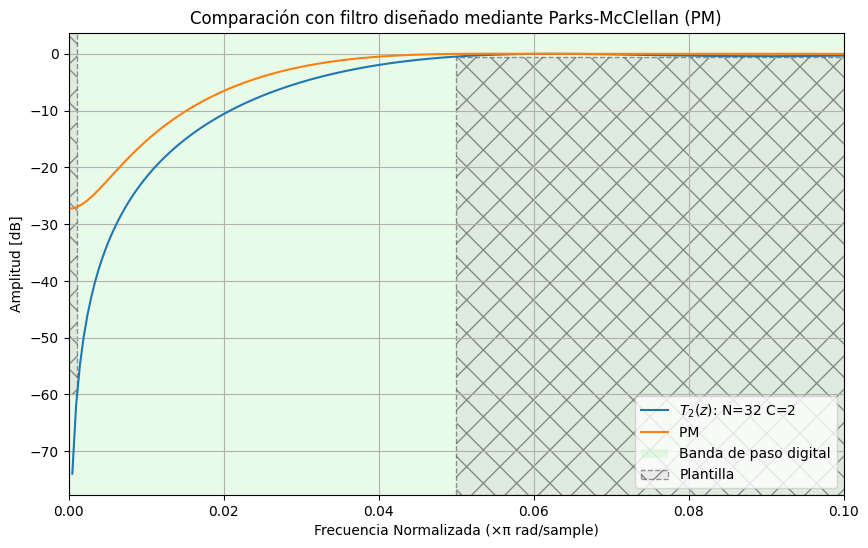

In [8]:
from pytc2.filtros_digitales import fir_design_pm
from pytc2.sistemas_lineales import plot_plantilla

### Rediseñamos para N = 32
# algunos parámetros se explicarán más abajo
t_filter = DC_PWL_removal_recursive_filter(samp_avg = 32, upsample = 1, cant_ma = cc, fpwl = 0.2 )
w_theoretical, H_theoretical = t_filter.frequency_response(bTeorica=True)

# normalization
w_theoretical = w_theoretical / np.pi

# Parámetros comunes del filtro Pasa Bajos
order = 88
fs = 2.0
wpass = 0.05
wstop = 0.0011
ripple = 0.5  # dB
attenuation = 60  # dB
lgrid = 16

cant_coef, band_edges, desired, weights = herrmann_lp_fir_order([wstop*np.pi, wpass*np.pi], [ripple, attenuation], ripple_in_db=True)

b_pm, _, _ = fir_design_pm(cant_coef, band_edges, desired[::-1], fs = 2*np.pi, weight= weights, grid_density=lgrid, filter_type='highpass')

# Comparar la respuesta en frecuencia de ambos filtros
w, h_pm = sig.freqz(b_pm, worN=w_theoretical, fs=2)

# Graficar ambas respuestas
plt.figure(figsize=(10, 6))
# Gráficos comparativos
plt.plot(w_theoretical, 20*np.log10(np.abs(H_theoretical)), label=f'$T_2(z)$: N=32 C=2')
plt.plot(w_theoretical, 20 * np.log10(np.abs(h_pm)), label='PM ')
plot_plantilla(filter_type = 'highpass' , fpass = wpass, ripple = ripple , fstop = wstop, attenuation = attenuation, fs = fs)
plt.title('Comparación con filtro diseñado mediante Parks-McClellan (PM)')
plt.xlabel('Frecuencia Normalizada (×π rad/sample)')
plt.ylabel('Amplitud [dB]')
plt.legend()
plt.grid()
ax = plt.gca()
ax.set_xlim( [0, .1 ])

plt.show()


Como se observa, la cantidad de coeficientes estimada **fue subestimada**, y es muy posible que el algoritmo de PM tenga problemas para ubicar ceros en torno a DC. Con esta comparativa el filtro propuesto cobra **aún más interés**. Sin embargo, en el último [artículo de Rick Lyons](https://www.dsprelated.com/showarticle/1383.php),   a partir de la transferencia $T_C(z)$, se propone interpolar su respuesta de forma tal de convertirla en una transferencia *tipo peine*. De esta manera podría aprovecharse sus ceros de transmisión para anular interferencias típicas del electrocardiograma (ECG) como

* el movimiento de muy baja frecuencia de la línea de base, provocado por factores tales como la respiración, actividad física, sudoración, degradación de los electrodos, entre otros.
* la frecuencia de 50/60 Hz de la línea eléctrica, y todas sus armónicas.

El efecto de interpolar por $U$ la respuesta al impulso de un filtro, visto desde la perspectiva frecuencial, es equivalente a comprimir la respuesta en frecuencia $U$ veces. Esto implica para $T_2(z)$

$$
T_2(\mathrm{z})\Big\vert_{\mathrm{z} = z^U} = \frac{1}{N^2} \cdot \frac{-1 + N^2.z^{(-U)(N-1)} -  (2 + 2.N^2).z^{-UN} +  N^2.z^{(-U)(N+1)} - z^{-2UN} }{ 1 -2.z^{-U} + z^{-2U} }
$$

Como la clase *DC_PWL_removal_recursive_filter* ya implementa el factor de sobremuestreo $U$, su efecto se verá más claro al analizar la respuesta en frecuencia de diferentes filtros

/tmp/ipykernel_28473/2847426380.py:14: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w_theoretical, 20*np.log10(np.abs(H_theoretical)), label=f'$T_{C}(z)$: U={uu} N={nn} C={cc}')


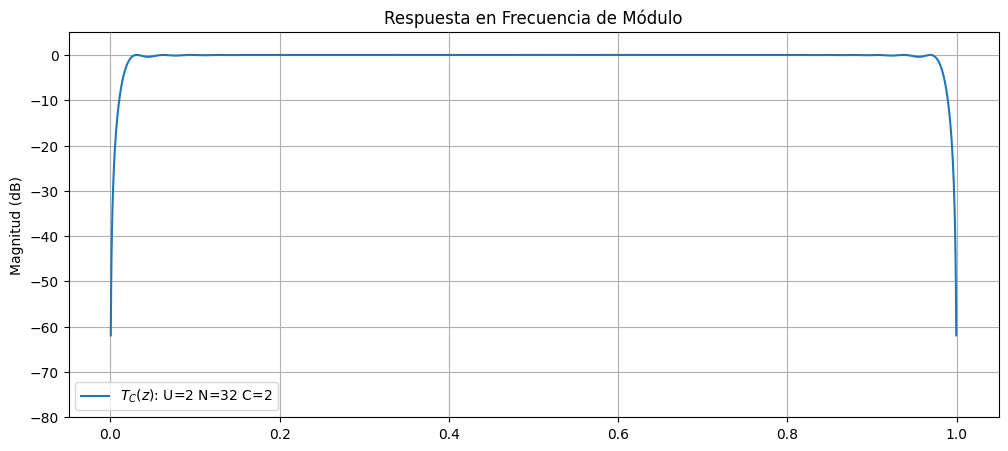

In [9]:
# cantidad de promediadores
cc = 2
uu = 2

# algunos parámetros se explicarán más abajo
t_filter = DC_PWL_removal_recursive_filter(samp_avg = nn, upsample = uu, cant_ma = cc )

w_theoretical, H_theoretical = t_filter.frequency_response(bTeorica=True)

# normalization
w_theoretical = w_theoretical / np.pi

fig = plt.figure(figsize=(12, 5))
plt.plot(w_theoretical, 20*np.log10(np.abs(H_theoretical)), label=f'$T_{C}(z)$: U={uu} N={nn} C={cc}')


plt.title(f'Respuesta en Frecuencia de Módulo')
plt.ylabel('Magnitud (dB)')
ax = plt.gca()
ax.set_ylim( [-80, 5 ])

plt.legend()
plt.grid(True)


El factor de sobremuestreo $U=2$ podría entenderse como la redefinición de la frecuencia de muestreo original, escalada $U$ veces
$$
f_{Su} = U . f_S
$$

De esta manera puede observarse que el 0 en DC de la transferencia $T_C(z)$ tiene infinitas réplicas en $k.f_S$, y como

$$
\frac{f_{Su}}{2} = \frac{U . f_S}{2} = f_S = k . f_S
$$

para $U=2$ simplemente coincide la primer réplica (k=1) con la nueva $\tfrac{f_{Su}}{2}$, es decir con la nueva **frecuencia de Nyquist**. Esto se hará aún más evidente para mayores factores de sobremuestreo.



/tmp/ipykernel_28473/1483265836.py:14: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w_theoretical, 20*np.log10(np.abs(H_theoretical)), label=f'$T_{C}(z)$: U={uu} N={nn} C={cc}')


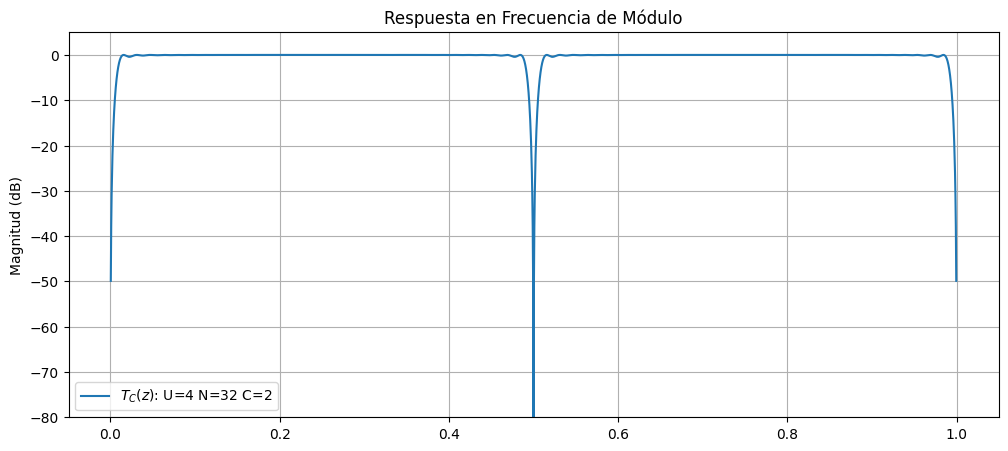

In [10]:
# cantidad de promediadores
cc = 2
uu = 4

# algunos parámetros se explicarán más abajo
t_filter = DC_PWL_removal_recursive_filter(samp_avg = nn, upsample = uu, cant_ma = cc )

w_theoretical, H_theoretical = t_filter.frequency_response(bTeorica=True)

# normalization
w_theoretical = w_theoretical / np.pi

fig = plt.figure(figsize=(12, 5))
plt.plot(w_theoretical, 20*np.log10(np.abs(H_theoretical)), label=f'$T_{C}(z)$: U={uu} N={nn} C={cc}')


plt.title(f'Respuesta en Frecuencia de Módulo')
plt.ylabel('Magnitud (dB)')
ax = plt.gca()
ax.set_ylim( [-80, 5 ])

plt.legend()
plt.grid(True)


/tmp/ipykernel_28473/1369545029.py:14: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w_theoretical, 20*np.log10(np.abs(H_theoretical)), label=f'$T_{C}(z)$: U={uu} N={nn} C={cc}')


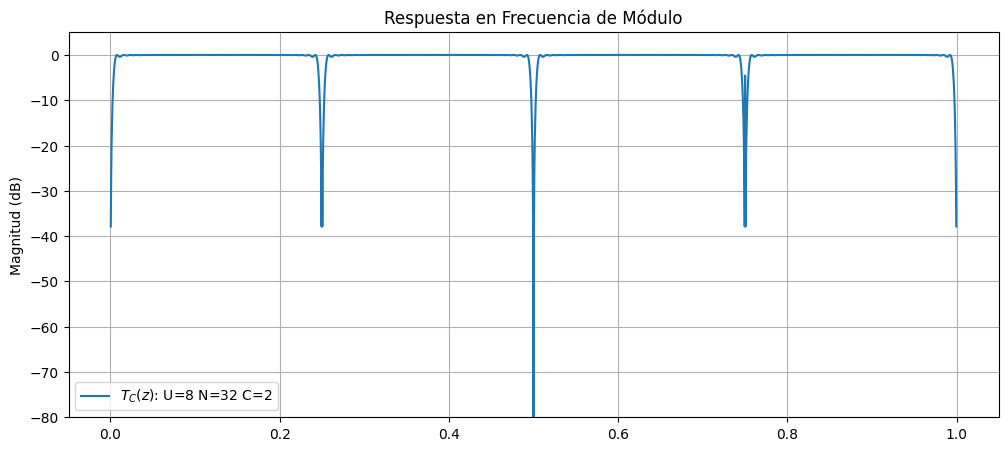

In [11]:
# cantidad de promediadores
cc = 2
uu = 8

# algunos parámetros se explicarán más abajo
t_filter = DC_PWL_removal_recursive_filter(samp_avg = nn, upsample = uu, cant_ma = cc )

w_theoretical, H_theoretical = t_filter.frequency_response(bTeorica=True)

# normalization
w_theoretical = w_theoretical / np.pi

fig = plt.figure(figsize=(12, 5))
plt.plot(w_theoretical, 20*np.log10(np.abs(H_theoretical)), label=f'$T_{C}(z)$: U={uu} N={nn} C={cc}')


plt.title(f'Respuesta en Frecuencia de Módulo')
plt.ylabel('Magnitud (dB)')
ax = plt.gca()
ax.set_ylim( [-80, 5 ])

plt.legend()
plt.grid(True)


Se observa que es conveniente que el factor $U$ sea $2^n$ múltiplo, de forma tal que  **siempre haya un cero en Nyquist**, y que los ceros de la *transferencia peine* ocurran en

$$ 
f_z = m \cdot k_z \quad \mathrm{para} \quad m=1,\,2,\, \ldots,\, \tfrac{U}{2}.
$$

siendo

$$
k_z = \frac{f_S}{U}
$$

De esta manera se obtiene un filtro para la remoción de interferencias típicas del registro de bio-potenciales, de forma compacta

$$
T_{C,U}(z) = T_C(\mathrm{z})\Big\vert_{\mathrm{z} = z^U} = z^{-\frac{(N-1).U.C}{2}} - \left( \frac{1}{N} \frac{1 - z^{-U.N}}{1 - z^{-U}} \right)^C
$$

luego para conocer su estructura, podemos recurrir al análisis simbólico nuevamente

In [38]:
# Con 2 promediadores
cc = 2
uu = 1
nn = 3

Tdc_removal_C = z**-(N-1)*C - Tma**C

Tdc_removal_cc = Tdc_removal_C.subs({C: cc, z:z**uu, N:nn})
# emprolijamos la expresion
#num, den = Tdc_removal_cc.as_numer_denom()

k, num, den = simplify_n_monic(Tdc_removal_cc)
#num = (sp.expand(num/(nn**cc*z**(cc*nn+cc)))).powsimp()
#den = (sp.expand(den/(nn**cc*z**(cc*nn+cc)))).powsimp()

display(num)
display(den)

Tdc_removal_cc = num/den

print_latex(a_equal_b_latex_s(f'T_{{C,U}}(z)', Tdc_removal_cc ))


-z**4 - 2*z**3 + 15*z**2 - 2*z - 1

9*z**4

<IPython.core.display.Math object>

### Aplicaciones a la electrocardiografía

Como se explicó anteriormente, se trata de un filtro de muy bajo costo computacional, demora constante y una respuesta de módulo muy prometedora. A partir de este momento, lo pondremos a prueba con señales de ECG reales.


### Referencias

 [1] Herrmann O., Rabiner L.R., and Chan D S K.:  Practical design rules for optimum finite impulse response lowpass digital filters, Bell System Techical Journal, vol. 52 (July-August), 1973.

 [2] Lars Wanhammar, Tapio Saramäki - Digital Filters Using MATLAB-Springer (2020)
 